## 0. Setup & Load Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

# Load dataset
df = pd.read_csv('Reviews.csv', engine='python', on_bad_lines='warn')

# Reproduce Sentiment column (same logic as team)
def get_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(get_sentiment)

# Sample 20000 rows (same seed as team)
df = df.sample(20000, random_state=42).reset_index(drop=True)

# Text Cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['Cleaned_Text'] = df['Text'].apply(clean_text)
df['review_length'] = df['Cleaned_Text'].apply(lambda x: len(x.split()))

print('Dataset shape:', df.shape)
df.head(3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_7239/1377447709.py:13: ParserWarning: Skipping line 219274: unexpected end of data

  df = pd.read_csv('Reviews.csv', engine='python', on_bad_lines='warn')


Dataset shape: (20000, 13)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,Cleaned_Text,review_length
0,58676,B0013P3KC6,A10C4O0Q0TWXOL,"Nancy Rector ""Author of A Painful Truth - The...",2,2,5,1315440000,Use this instead of sugar.. PLEASE!,Here is the jist: Sugar = Toxic Xylitol = Hea...,Positive,jist sugar toxic xylitol healing br br kidding...,60
1,30237,B000DZFMEQ,AX4RADQ4X9FTX,"C. Bonfiglio ""emmasmom""",2,2,4,1198108800,my daughter ate it!,My daughter is on the autism spectrum and very...,Positive,daughter autism spectrum picky also recently d...,88
2,189811,B001EO5Q64,A1LHZGATJKUNWL,Ming J. Yang,1,2,5,1291939200,Recommanded it to my hair salon customers.,I have bought many packs of this coconut oil.I...,Positive,bought many packs coconut oil also recommanded...,12


---
## 1. EDA — Graphs & Visualizations

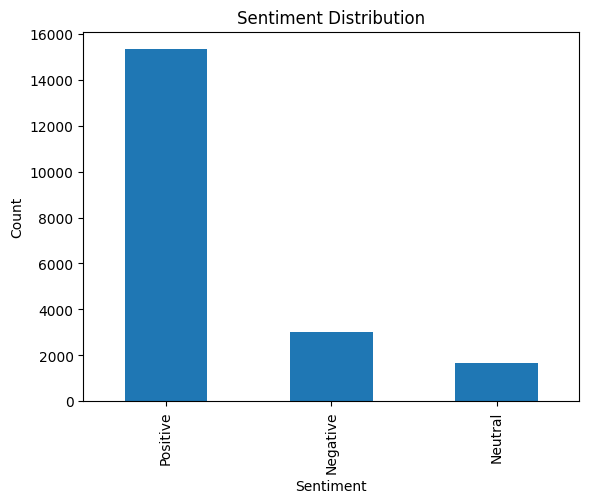

In [6]:
# EDA
# -----------------------------------
import matplotlib.pyplot as plt

# 1. Sentiment Distribution
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


### 1.3 Review Length Distribution by Sentiment

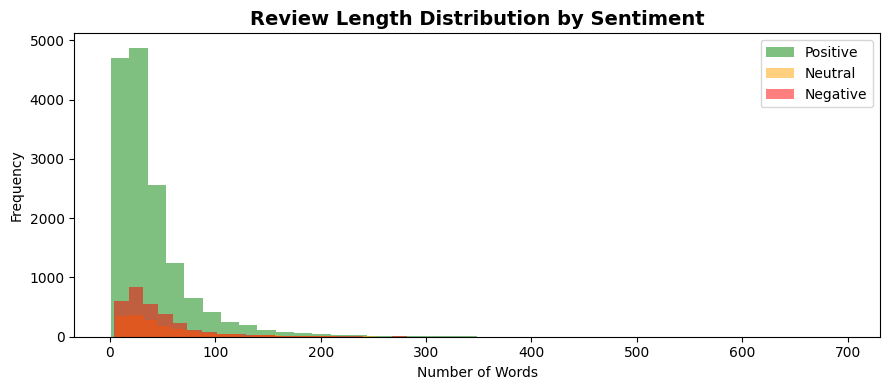

             count  mean   std  min   25%   50%   75%    max
Sentiment                                                   
Negative    3009.0  44.7  42.4  4.0  20.0  33.0  54.0  559.0
Neutral     1661.0  50.6  46.2  6.0  21.0  37.0  64.0  524.0
Positive   15330.0  39.8  40.4  1.0  16.0  27.0  48.0  696.0


In [7]:
plt.figure(figsize=(9, 4))
for sentiment, color in [('Positive', 'green'), ('Neutral', 'orange'), ('Negative', 'red')]:
    subset = df[df['Sentiment'] == sentiment]['review_length']
    plt.hist(subset, bins=40, alpha=0.5, label=sentiment, color=color)

plt.title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby('Sentiment')['review_length'].describe().round(1))

### 1.4 Top 20 Most Frequent Words (Overall)

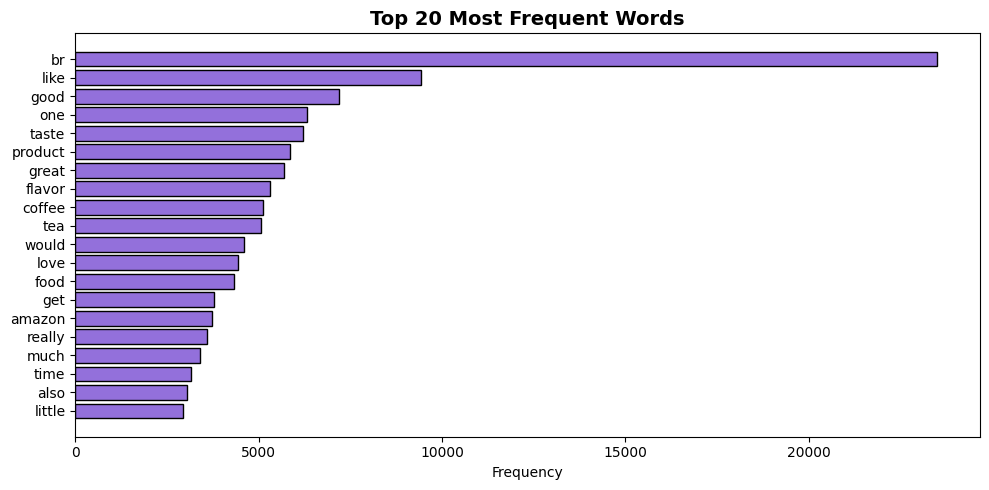

In [8]:
all_words = ' '.join(df['Cleaned_Text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='mediumpurple', edgecolor='black')
plt.title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

### 1.5 Sentiment Proportion — Pie Chart

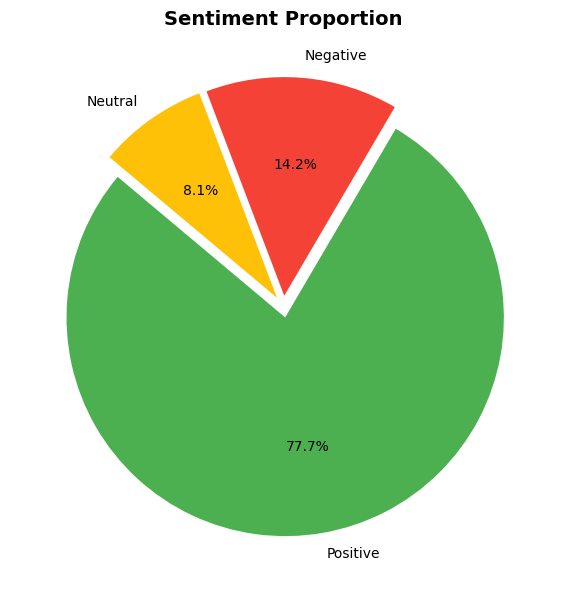

In [11]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=['#4CAF50', '#F44336', '#FFC107'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05, 0.05, 0.05]
)
plt.title('Sentiment Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Category Creation from Text

We create product categories by looking for **keyword patterns** in the review text.  
This is a rule-based text categorization — no model needed.

In [12]:
# Define keyword rules for categories
category_keywords = {
    'Food & Snacks':   ['food', 'snack', 'chip', 'cookie', 'cracker', 'candy', 'chocolate',
                        'cereal', 'granola', 'pretzel', 'popcorn', 'nut', 'peanut', 'almond'],
    'Beverages':       ['coffee', 'tea', 'drink', 'juice', 'water', 'soda', 'beverage',
                        'lemonade', 'energy', 'wine', 'beer', 'brew', 'espresso'],
    'Health & Organic':['organic', 'natural', 'healthy', 'vitamin', 'supplement', 'protein',
                        'gluten', 'vegan', 'keto', 'diet', 'fiber', 'probiotic', 'herbal'],
    'Pet Food':        ['dog', 'cat', 'pet', 'puppy', 'kitten', 'treat', 'kibble', 'paw',
                        'animal', 'fur', 'vet'],
    'Condiments & Spices': ['sauce', 'spice', 'seasoning', 'salt', 'pepper', 'vinegar',
                            'ketchup', 'mustard', 'mayo', 'dressing', 'herb', 'garlic'],
    'Dairy & Alternatives': ['milk', 'cheese', 'butter', 'cream', 'yogurt', 'dairy',
                             'almond milk', 'soy milk', 'lactose'],
    'Pasta & Grains':  ['pasta', 'rice', 'wheat', 'bread', 'flour', 'grain', 'oat',
                        'noodle', 'quinoa', 'barley', 'corn', 'maize'],
}

def assign_category(text):
    text_lower = str(text).lower()
    for category, keywords in category_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                return category
    return 'Other'

df['Category'] = df['Text'].apply(assign_category)

print('Category distribution:')
print(df['Category'].value_counts())

Category distribution:
Category
Food & Snacks           8150
Beverages               4808
Other                   2925
Pet Food                1287
Pasta & Grains           925
Health & Organic         918
Condiments & Spices      731
Dairy & Alternatives     256
Name: count, dtype: int64


### 2.1 Category Distribution — Bar Chart

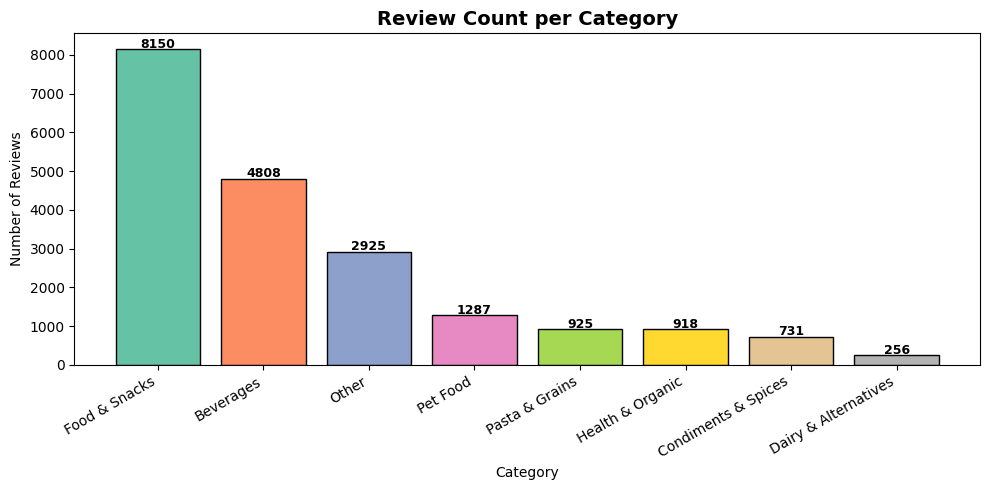

In [13]:
cat_counts = df['Category'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(cat_counts.index, cat_counts.values,
               color=sns.color_palette('Set2', len(cat_counts)),
               edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             str(int(bar.get_height())),
             ha='center', fontsize=9, fontweight='bold')

plt.title('Review Count per Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Category-wise Analysis

### 3.1 Sentiment Distribution per Category (Stacked Bar)

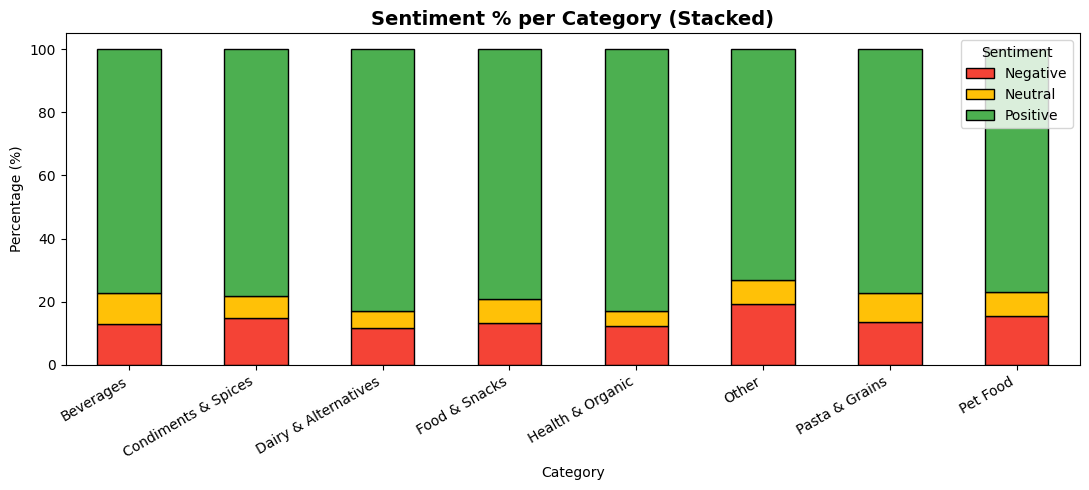

In [14]:
cat_sentiment = df.groupby(['Category', 'Sentiment']).size().unstack(fill_value=0)

# Normalize to proportions
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

cat_sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 5),
    color=['#F44336', '#FFC107', '#4CAF50'],
    edgecolor='black'
)

plt.title('Sentiment % per Category (Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()

### 3.2 Average Star Score per Category

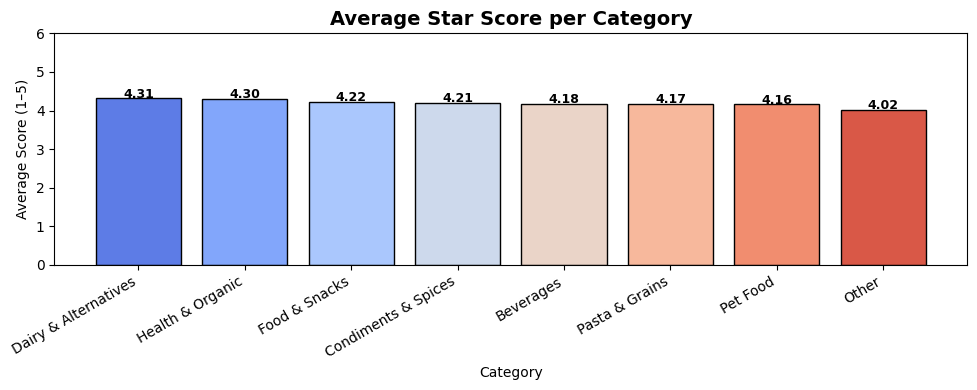

In [15]:
avg_score = df.groupby('Category')['Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(avg_score.index, avg_score.values,
               color=sns.color_palette('coolwarm', len(avg_score)),
               edgecolor='black')

for bar, val in zip(bars, avg_score.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{val:.2f}',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Average Star Score per Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Score (1–5)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

### 3.3 Average Review Length per Category

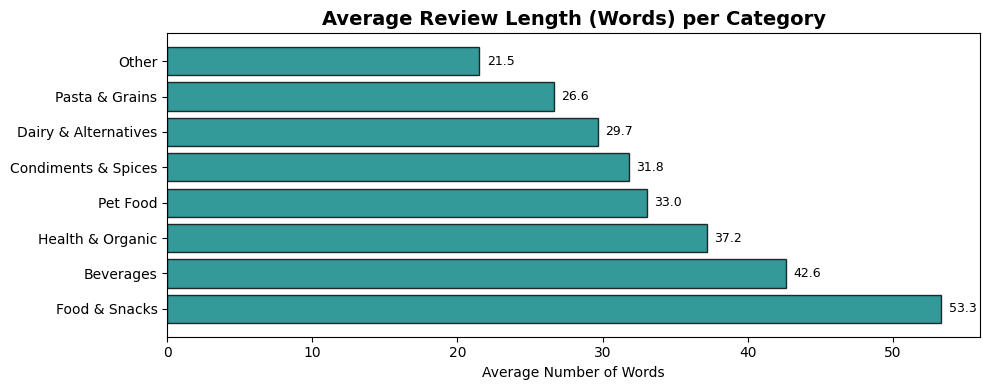

In [16]:
avg_len = df.groupby('Category')['review_length'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.barh(avg_len.index, avg_len.values,
         color='teal', edgecolor='black', alpha=0.8)

for i, val in enumerate(avg_len.values):
    plt.text(val + 0.5, i, f'{val:.1f}', va='center', fontsize=9)

plt.title('Average Review Length (Words) per Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Number of Words')
plt.tight_layout()
plt.show()

### 3.4 Top 10 Words per Category

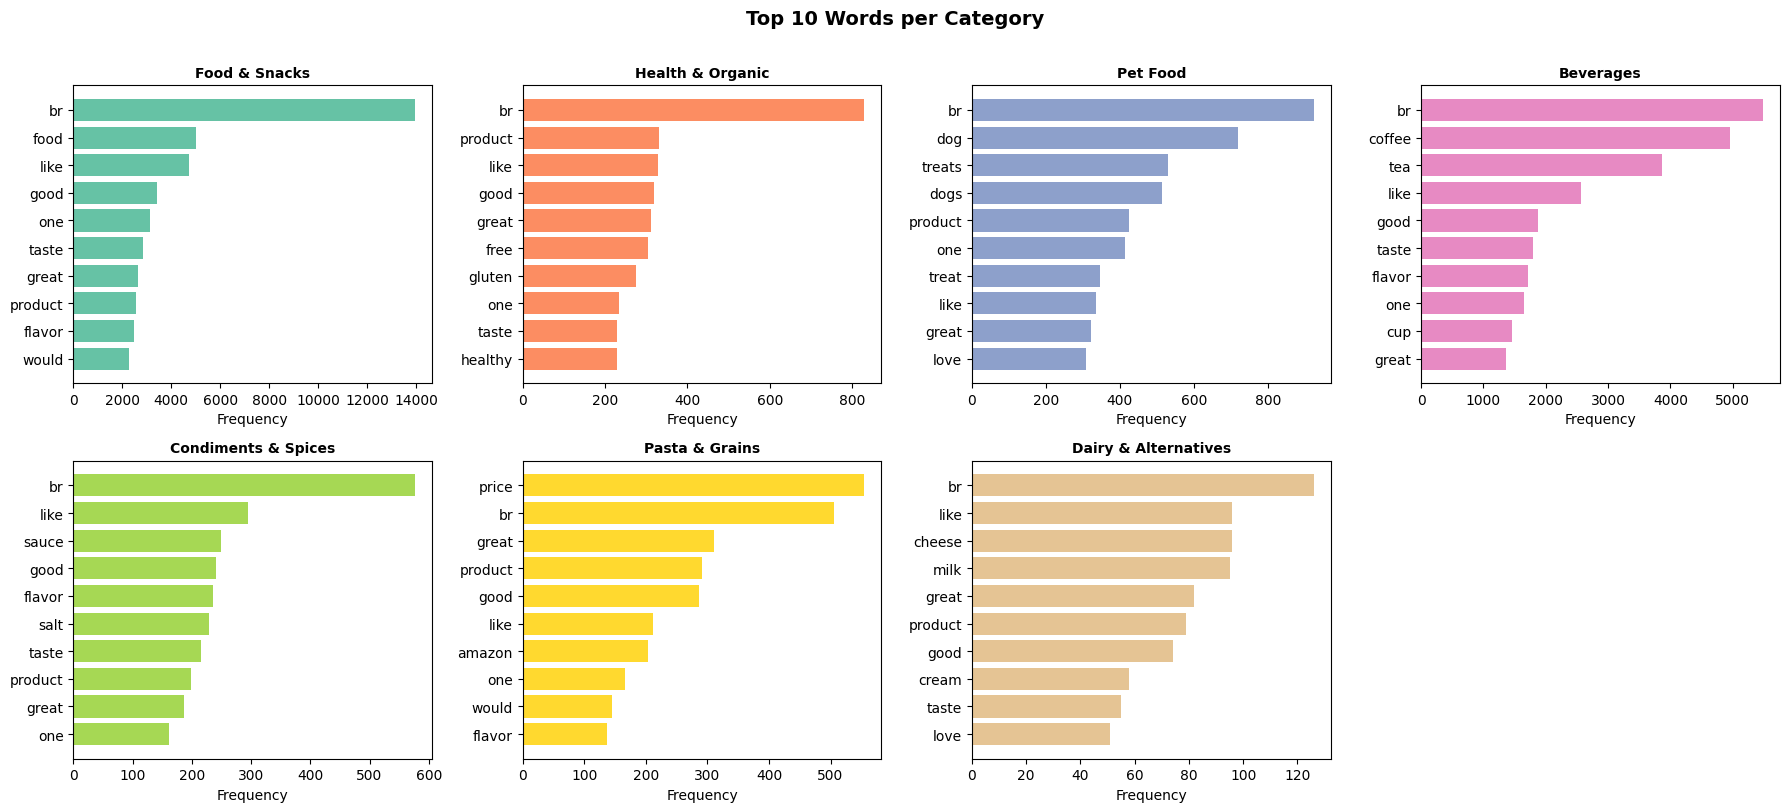

In [17]:
categories_to_plot = [c for c in df['Category'].unique() if c != 'Other']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, cat in enumerate(categories_to_plot):
    subset = df[df['Category'] == cat]['Cleaned_Text']
    words = ' '.join(subset).split()
    top10 = Counter(words).most_common(10)
    w, c = zip(*top10) if top10 else ([], [])
    axes[idx].barh(list(w)[::-1], list(c)[::-1],
                   color=sns.color_palette('Set2')[idx % 8])
    axes[idx].set_title(cat, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Words per Category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Category-wise Summary Table

In [18]:
summary = df.groupby('Category').agg(
    Total_Reviews=('Text', 'count'),
    Avg_Score=('Score', 'mean'),
    Avg_Length=('review_length', 'mean'),
    Positive_Count=('Sentiment', lambda x: (x == 'Positive').sum()),
    Neutral_Count=('Sentiment', lambda x: (x == 'Neutral').sum()),
    Negative_Count=('Sentiment', lambda x: (x == 'Negative').sum()),
).round(2)

summary['Positive_%'] = (summary['Positive_Count'] / summary['Total_Reviews'] * 100).round(1)
summary['Negative_%'] = (summary['Negative_Count'] / summary['Total_Reviews'] * 100).round(1)

summary.sort_values('Total_Reviews', ascending=False)

,Total_Reviews,Avg_Score,Avg_Length,Positive_Count,Neutral_Count,Negative_Count,Positive_%,Negative_%
Category,,,,,,,,
Food & Snacks,8150,4.22,53.34,6441,624,1085,79.0,13.3
Beverages,4808,4.18,42.63,3713,475,620,77.2,12.9
Other,2925,4.02,21.52,2134,229,562,73.0,19.2
Pet Food,1287,4.16,33.04,990,97,200,76.9,15.5
Pasta & Grains,925,4.17,26.63,713,87,125,77.1,13.5
Health & Organic,918,4.30,37.20,761,44,113,82.9,12.3
Condiments & Spices,731,4.21,31.80,571,51,109,78.1,14.9
Dairy & Alternatives,256,4.31,29.70,212,14,30,82.8,11.7
